<a href="https://colab.research.google.com/github/vikasch123/AttacksOnIndianStudentsAnalysis/blob/main/notebook.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd

# Load your dataset
file_path = '/content/sample_data/RS_Session_265_AS_190_A_and_B.csv'
df = pd.read_csv(file_path)

# Drop the 'Sl. No.' column as it’s not needed
df = df.drop('Sl. No.', axis=1)

# Add the 'Total Attacks' column
df['Total Attacks'] = df['2022'] + df['2023'] + df['2024']
print(df)

            Name of Country  2022  2023  2024  Total Attacks
0                 Australia     1     2     1              4
1  United States of America     1     4     2              7
2            United Kingdom     1     7     4             12
3                     Italy     0     0     3              3
4                    Russia     0    12     1             13
5                    Canada     1     1     5              7
6                   Ireland     0     1     3              4
7                      Iran     0     1     0              1
8                     Total     4    28    19             51


In [ ]:
num_columns=df.shape[1]
print(num_columns)
df.iloc[num_columns-1]

5


,4
Name of Country,Russia
2022,0
2023,12
2024,1
Total Attacks,13


**as we dont need the last total row at the end for country wise analysis we shall remove it**

In [ ]:
df=df[df['Name of Country']!= 'Total']
print(df)

            Name of Country  2022  2023  2024  Total Attacks
0                 Australia     1     2     1              4
1  United States of America     1     4     2              7
2            United Kingdom     1     7     4             12
3                     Italy     0     0     3              3
4                    Russia     0    12     1             13
5                    Canada     1     1     5              7
6                   Ireland     0     1     3              4
7                      Iran     0     1     0              1


In [ ]:
print(df.isnull().sum())

Name of Country    0
2022               0
2023               0
2024               0
Total Attacks      0
dtype: int64


In [ ]:
total_2022 = df['2022'].sum()
total_2023 = df['2023'].sum()
total_2024 = df['2024'].sum()
print(f"Total Attacks in 2022: {total_2022}")
print(f"Total Attacks in 2023: {total_2023}")
print(f"Total Attacks in 2024: {total_2024}")

Total Attacks in 2022: 4
Total Attacks in 2023: 28
Total Attacks in 2024: 19


In [ ]:
print(df.loc[:, 'Total Attacks'])

0     4
1     7
2    12
3     3
4    13
5     7
6     4
7     1
Name: Total Attacks, dtype: int64


Identifing the country with the highest total attacks.

In [ ]:
max_attacks_country = df.loc[df['Total Attacks'].idxmax(), 'Name of Country']
max_attacks_value = df['Total Attacks'].max()
print(f"Country with the most attacks: {max_attacks_country} with {max_attacks_value} attacks")

Country with the most attacks: Russia with 13 attacks


Damm, Russia is not welcoming guys :(
  

Analyzing changing trends

In [ ]:
df['Change 2022-2023'] = df['2023'] - df['2022']
df['Change 2023-2024'] = df['2024'] - df['2023']
print(df)

            Name of Country  2022  2023  2024  Total Attacks  \
0                 Australia     1     2     1              4   
1  United States of America     1     4     2              7   
2            United Kingdom     1     7     4             12   
3                     Italy     0     0     3              3   
4                    Russia     0    12     1             13   
5                    Canada     1     1     5              7   
6                   Ireland     0     1     3              4   
7                      Iran     0     1     0              1   

   Change 2022-2023  Change 2023-2024  
0                 1                -1  
1                 3                -2  
2                 6                -3  
3                 0                 3  
4                12               -11  
5                 0                 4  
6                 1                 2  
7                 1                -1  


Sort by Total Attacks: Sort the DataFrame to see which countries have the highest number of attacks.


In [ ]:
df_sorted = df.sort_values(by='Total Attacks', ascending=False)
print(df_sorted)

            Name of Country  2022  2023  2024  Total Attacks  \
4                    Russia     0    12     1             13   
2            United Kingdom     1     7     4             12   
5                    Canada     1     1     5              7   
1  United States of America     1     4     2              7   
6                   Ireland     0     1     3              4   
0                 Australia     1     2     1              4   
3                     Italy     0     0     3              3   
7                      Iran     0     1     0              1   

   Change 2022-2023  Change 2023-2024  
4                12               -11  
2                 6                -3  
5                 0                 4  
1                 3                -2  
6                 1                 2  
0                 1                -1  
3                 0                 3  
7                 1                -1  


In [ ]:
high_risk = df[df['Total Attacks'] > 5]
print("High-risk countries (more than 5 total attacks):")
print(high_risk)

High-risk countries (more than 5 total attacks):
            Name of Country  2022  2023  2024  Total Attacks  \
1  United States of America     1     4     2              7   
2            United Kingdom     1     7     4             12   
4                    Russia     0    12     1             13   
5                    Canada     1     1     5              7   

   Change 2022-2023  Change 2023-2024  
1                 3                -2  
2                 6                -3  
4                12               -11  
5                 0                 4  


Visualizing the data for a clear picture

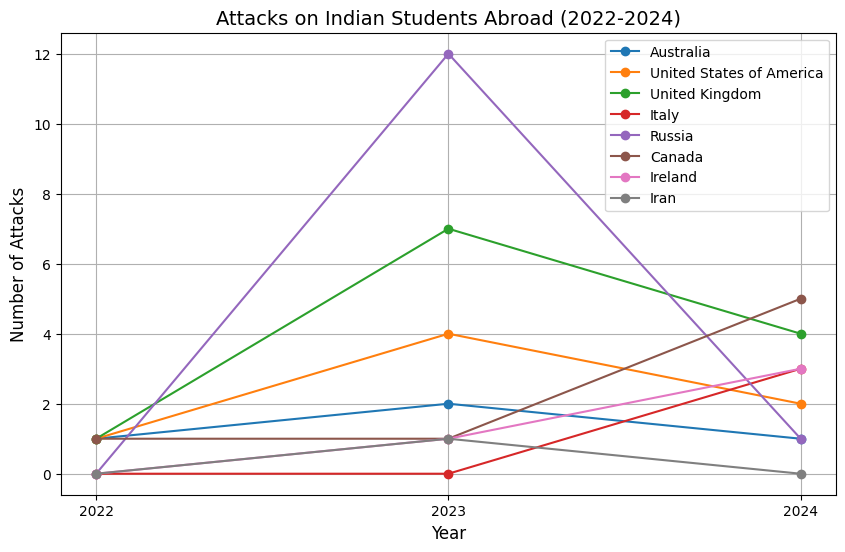

In [ ]:
import matplotlib.pyplot as plt
# Set the figure size for better readability
plt.figure(figsize=(10, 6))

# Plot a line for each country
for index, row in df.iterrows():
    plt.plot(['2022', '2023', '2024'], [row['2022'], row['2023'], row['2024']],
             marker='o', label=row['Name of Country'])

# Add titles and labels
plt.title('Attacks on Indian Students Abroad (2022-2024)', fontsize=14)
plt.xlabel('Year', fontsize=12)
plt.ylabel('Number of Attacks', fontsize=12)

# Add a legend to identify each country
plt.legend()

# Add a grid for better readability
plt.grid(True)

# Display the plot
plt.show()

# Key Insight: Russia has a huge spike in 2023 (12 attacks) and then drops sharply in 2024 (1 attack). The United Kingdom also peaks in 2023 (7 attacks). Canada shows a steady increase, peaking in 2024 (5 attacks).

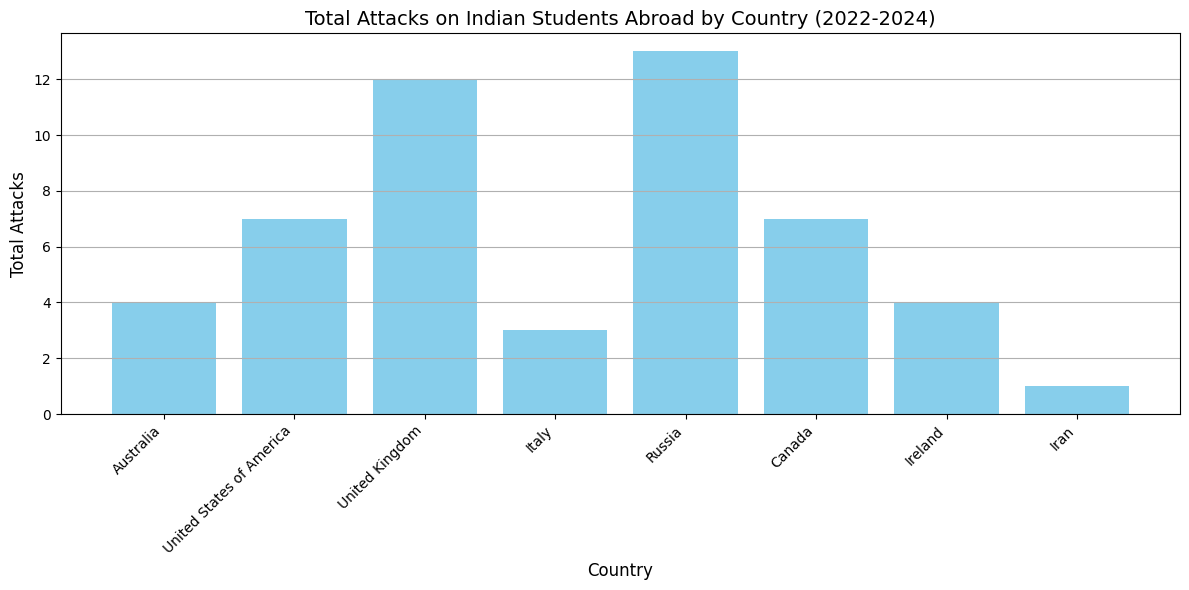

In [ ]:
# Set the figure size
plt.figure(figsize=(12, 6))

# Create a bar chart
plt.bar(df['Name of Country'], df['Total Attacks'], color='skyblue')

# Add titles and labels
plt.title('Total Attacks on Indian Students Abroad by Country (2022-2024)', fontsize=14)
plt.xlabel('Country', fontsize=12)
plt.ylabel('Total Attacks', fontsize=12)

# Rotate x-axis labels for better readability (since country names are long)
plt.xticks(rotation=45, ha='right')

# Add a grid on the y-axis
plt.grid(True, axis='y')

# Adjust layout to prevent label cutoff
plt.tight_layout()

# Display the plot
plt.show()

# Key Insight: This highlights which countries are the most dangerous for Indian students over the three years.